# Phase 2 — Segmentation via Clustering
---
## [STEP 2.0] Import Libraries Tambahan


In [5]:
# Clustering Libraries
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

import numpy as np
import pandas as pd
import warnings
import pickle
warnings.filterwarnings('ignore')


---
## [STEP 2.1] Persiapan Data untuk Clustering

#### 2.1.1 — Load Dataset & Sampling


In [6]:
# 1. Load dataset scaled untuk input model
df_scaled = pd.read_csv('scaled_lending_club.csv')

# 2. Load dataset unscaled (unit asli) untuk profiling centroid nanti
df_unscaled = pd.read_csv('cleaned_lending_club.csv')

# 3. Load dataset referensi status pinjaman
loan_status_ref = pd.read_csv('loan_status_reference.csv')['loan_status']

assert df_unscaled.shape[0] == df_scaled.shape[0], "Row count mismatch!"

# Lakukan random sampling 10.000 baris
X_sample_scaled = df_scaled.sample(n=10000, random_state=42)
sample_indices = X_sample_scaled.index

# Siapkan data referensi berdasarkan index sampling
loan_status_sample = loan_status_ref.iloc[sample_indices].reset_index(drop=True)

# Ekstrak data raw/unscaled untuk index yang sama
X_sample_raw = df_unscaled.loc[sample_indices].reset_index(drop=True)
# Kembalikan annual_inc dari log1p ke nilai asal (dolar)
X_sample_raw['annual_inc'] = np.expm1(X_sample_raw['annual_inc'])

X_sample_scaled = X_sample_scaled.reset_index(drop=True)

print(f"Shape X_sample_scaled  : {X_sample_scaled.shape}")
print(f"Shape X_sample_raw     : {X_sample_raw.shape}")


Shape X_sample_scaled  : (10000, 8)
Shape X_sample_raw     : (10000, 8)


#### 2.1.2 — Pemilihan Fitur Clustering

Fitur purpose_small_business dikeluarkan dari variabel input kalkulasi clustering karena sifatnya sebagai variabel biner yang memiliki persentase minoritas ekstrem (~1%) dapat menciptakan distorsi skala yang sangat besar setelah proses standardisasi. Akibatnya, nilai ekstrem dari fitur tunggal ini akan mendominasi metrik Jarak Euclidean, sehingga memaksa algoritma mengabaikan karakteristik finansial kontinyu lainnya (seperti income, skor FICO, dan loan amount) dan murni hanya membelah data menjadi peminjam usaha kecil versus non-usaha kecil. Dengan mengeluarkannya dari kalkulasi jarak namun tetap memanfaatkannya pada fase evaluasi pasca-clustering (cross-profiling), kita memungkinkan algoritma membentuk segmen secara alami berdasarkan keseluruhan kesehatan finansial nasabah, sembari tetap memperoleh wawasan terkait tren pinjaman usaha kecil pada tiap segmen yang terbentuk.


In [7]:
semua_fitur = X_sample_scaled.columns.tolist()

# Keluarkan purpose_small_business dari input model clustering
clustering_input_features = [f for f in semua_fitur if f != 'purpose_small_business']

# X_scaled final yang akan masuk ke K-Means, DBSCAN, Agglomerative
X_scaled_final = X_sample_scaled[clustering_input_features].values

print(f"Fitur untuk clustering ({len(clustering_input_features)}): {clustering_input_features}")


Fitur untuk clustering (7): ['loan_amnt', 'grade', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'emp_length']


#### 2.1.3 — Analisis Varians PCA (Diagnostik)
Potongan kode berikut berfungsi untuk mendiagnosis seberapa banyak *Cumulative Explained Variance* (Informasi Kumulatif) yang bisa diselamatkan jika kita ingin melakukan reduksi dimensi sesungguhnya untuk pemodelan (berbeda dengan *scatter plot* 2D di atas).

=== Cumulative Explained Variance PCA ===
1 komponen -> 26.86%
2 komponen -> 49.09%
3 komponen -> 63.81%
4 komponen -> 77.30%
5 komponen -> 87.91%
6 komponen -> 94.35%
7 komponen -> 100.00%


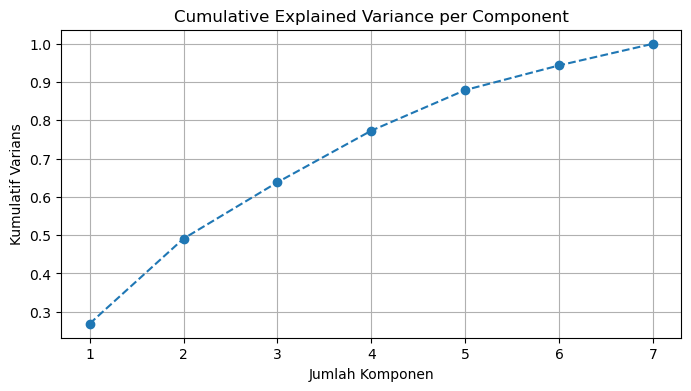

In [8]:
# Fit PCA tanpa batasan komponen untuk melihat distribusi varians keseluruhan
pca_full = PCA().fit(X_scaled_final)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print("=== Cumulative Explained Variance PCA ===")
for i, v in enumerate(cum_var, 1):
    print(f"{i} komponen -> {v*100:.2f}%")
    
# Tampilkan plot sederhana
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance per Component')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Kumulatif Varians')
plt.grid(True)
plt.show()


**Justifikasi Pemilihan `n_components`:**
- Berdasarkan hasil diagnostik di atas, jika kita menargetkan untuk mempertahankan *Explained Variance* sebesar **85% - 95%** untuk pemodelan (reduksi dimensi), kita membutuhkan setidaknya **5 hingga 6 komponen**.

In [9]:
# Lakukan PCA 2D pada fitur final ini sebagai input clustering scatter plot
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_scaled_final)

---
## [STEP 2.2] K-Means Clustering

#### 2.2.1 — Elbow Method & Silhouette Score


In [10]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil = silhouette_score(X_pca, labels)
    silhouette_scores.append(sil)
    
    print(f"K={k}: Inertia={km.inertia_:.2f}, Silhouette={sil:.4f}")


K=2: Inertia=49247.00, Silhouette=0.1905
K=3: Inertia=41776.38, Silhouette=0.1776
K=4: Inertia=37651.14, Silhouette=0.1683
K=5: Inertia=34355.14, Silhouette=0.1621
K=6: Inertia=32080.15, Silhouette=0.1639
K=7: Inertia=30312.06, Silhouette=0.1580
K=8: Inertia=28899.70, Silhouette=0.1525
K=9: Inertia=27549.79, Silhouette=0.1520
K=10: Inertia=26398.33, Silhouette=0.1519


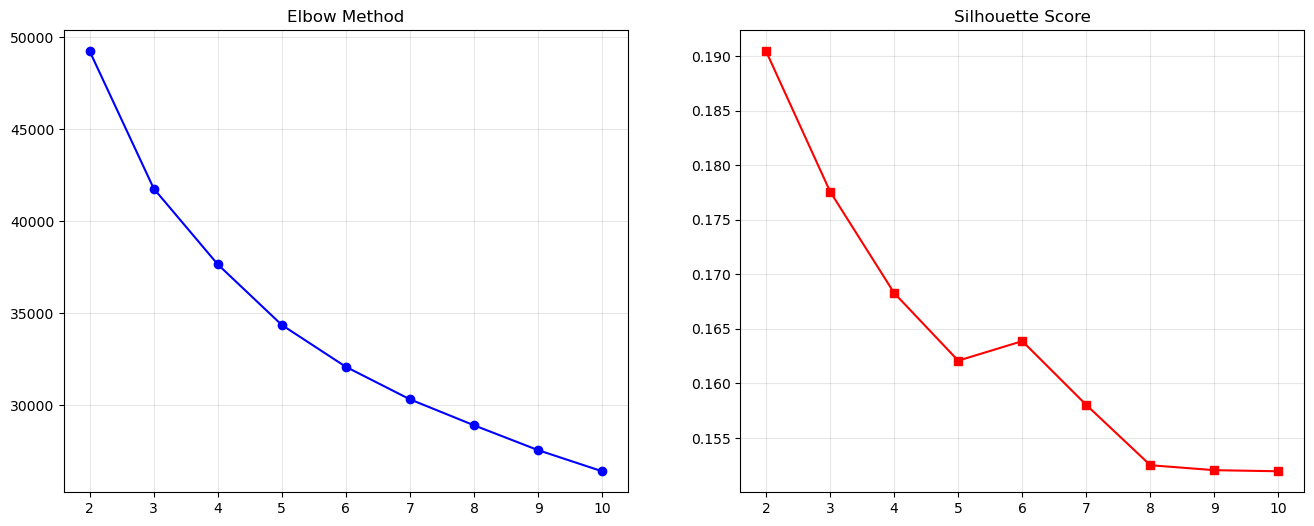

In [11]:
# Visualisasi Elbow & Silhouette
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(K_range)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'rs-')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(K_range)
axes[1].grid(True, alpha=0.3)
plt.show()

**Justifikasi Evaluasi K (Elbow & Silhouette):**
- **Elbow Method (Kiri):** Metrik ini memplot nilai *Inertia* (jumlah kuadrat jarak antara data point dengan centroid klaster terdekatnya). Tujuan kita adalah mencari titik 'siku' (*elbow*) di mana kurva mulai melandai secara signifikan. Titik ini merepresentasikan jumlah klaster (K) di mana penambahan klaster baru tidak lagi memberikan penurunan varians/inersia yang berarti (mencegah *over-fragmentation*).
- **Silhouette Score (Kanan):** Metrik ini secara matematis mengukur seberapa kohesif sebuah titik data terhadap klasternya sendiri dibandingkan dengan seberapa terpisahnya ia dari klaster tetangga. Nilai yang lebih mendekati 1 menunjukkan struktur klaster yang kokoh.

Karena kurva *Elbow* pada data riil finansial seringkali sangat landai dan ambigu (tidak memiliki tekukan siku yang tajam), **kita menetapkan `optimal_k` secara otomatis berdasarkan nilai mutlak tertinggi dari grafik *Silhouette Score***. Ini memberikan landasan objektif dan matematis (bukan tebakan visual) bahwa jumlah *cluster* tersebut adalah pemisahan batas profil nasabah yang paling tegas.

Optimal K terpilih secara otomatis: 2
Silhouette: 0.1905, DB: 1.8726, CH: 2463.4137


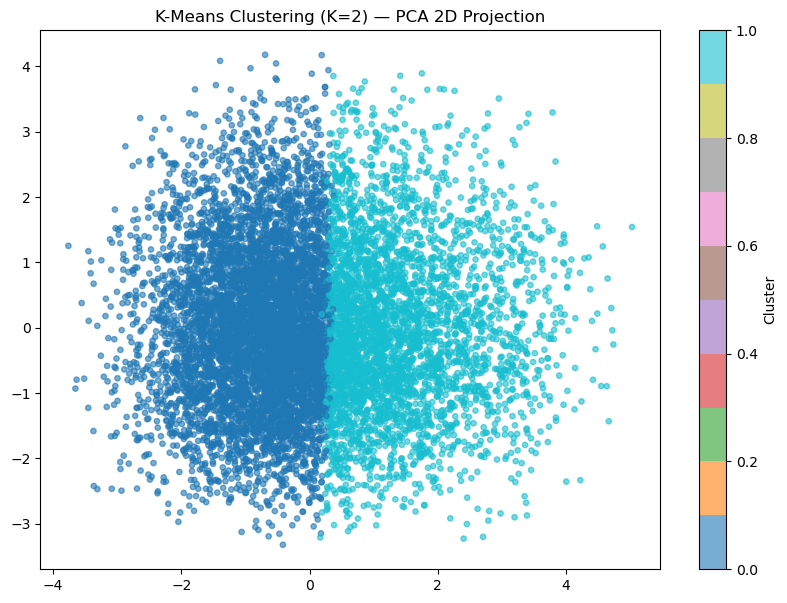

In [12]:
# Optimal K ditentukan secara otomatis dari nilai silhouette terbesar
optimal_k = list(K_range)[np.argmax(silhouette_scores)]
print(f"Optimal K terpilih secara otomatis: {optimal_k}")

# Fit K-Means Final
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_pca)

# Evaluasi model K-Means
sil_score = silhouette_score(X_pca, kmeans_labels)
db_score  = davies_bouldin_score(X_pca, kmeans_labels)
ch_score  = calinski_harabasz_score(X_pca, kmeans_labels)
print(f"Silhouette: {sil_score:.4f}, DB: {db_score:.4f}, CH: {ch_score:.4f}")

# Visualisasi PCA K-Means
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering (K={optimal_k}) — PCA 2D Projection')
plt.show()



---
## [STEP 2.3] Hierarchical Clustering


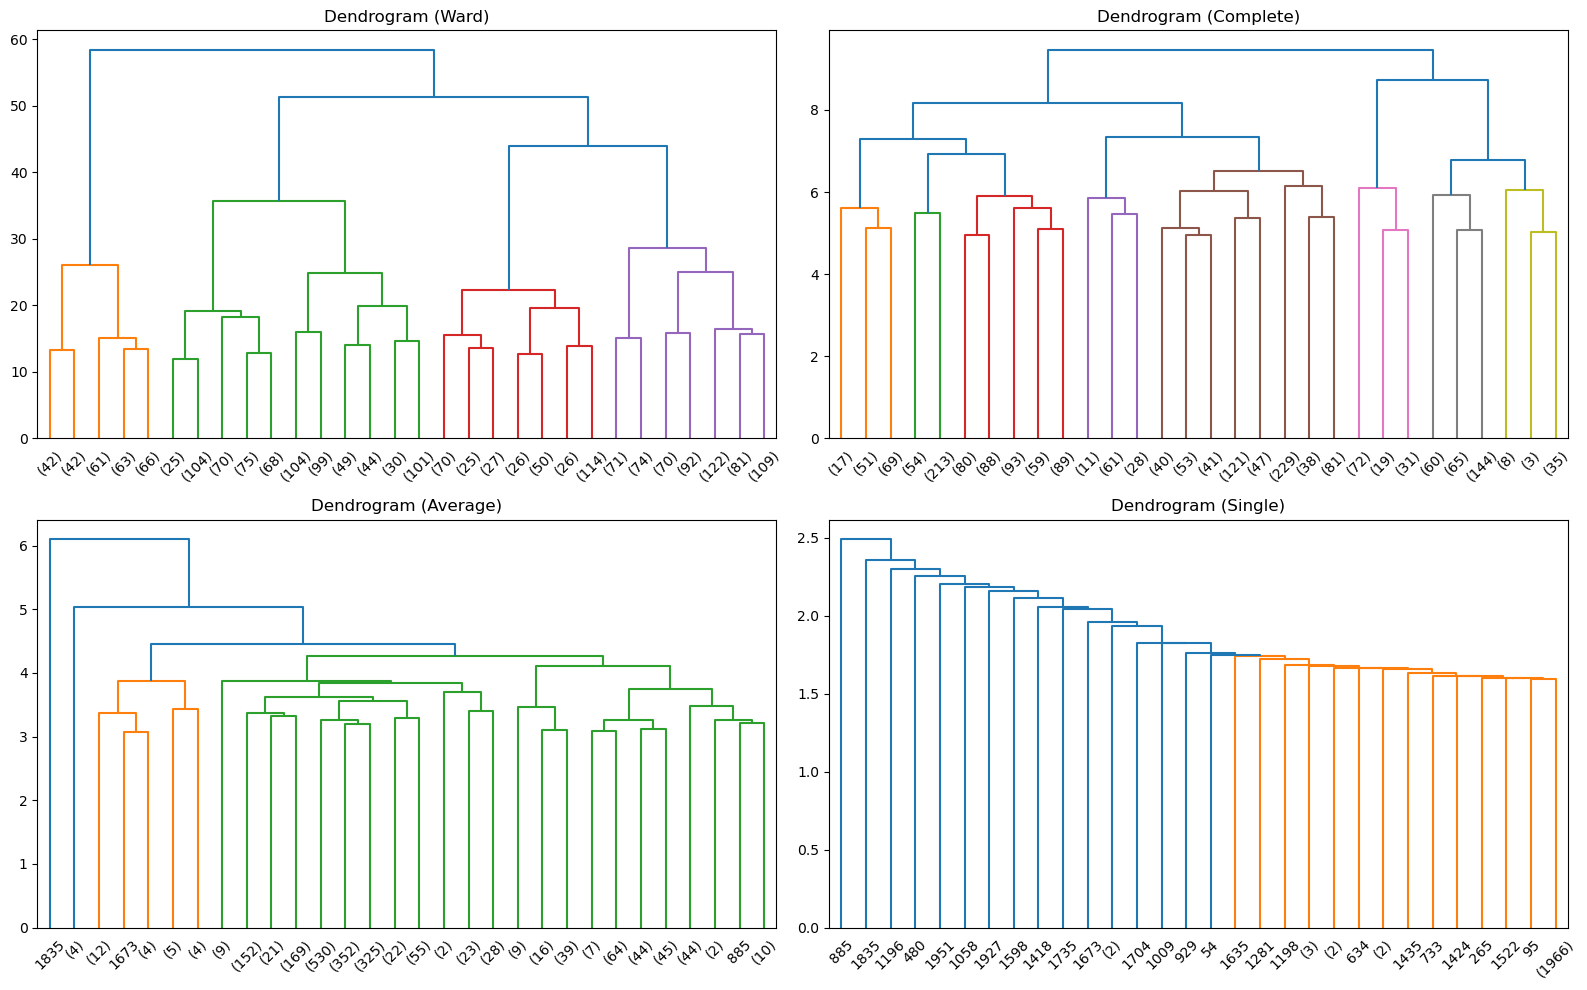

In [17]:
n_hier = 2000
idx_hier = np.random.RandomState(42).choice(len(X_scaled_final), size=n_hier, replace=False)
X_hier = X_scaled_final[idx_hier]

linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16,10))

for ax, method in zip(axes.flatten(), linkage_methods):
    Z = linkage(X_hier, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, show_leaf_counts=True, color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'Dendrogram ({method.capitalize()})')
plt.tight_layout()
plt.show()




**Justifikasi Pemilihan Metode `ward` (Tanpa Metrik Matematis):**
- Berdasarkan visualisasi Dendrogram di atas, metode **Ward** menunjukkan struktur hierarki yang paling seimbang dan tegas. Cabang-cabang utamanya terpisah dengan ketinggian jarak yang signifikan, menandakan klaster-klaster yang terbentuk memiliki perbedaan karakteristik yang jelas dan varians internal yang padat.
- Sebaliknya, metode seperti *Single* atau *Average* seringkali memperlihatkan pola anak tangga yang condong ke satu sisi. Fenomena ini disebut **efek Chaining**, di mana algoritma cenderung menggumpalkan mayoritas data ke dalam satu klaster raksasa dan menyisakan klaster lain hanya berisi segelintir data pencilan (*outlier*).
- Secara bisnis (Lending Club), kita membutuhkan segmentasi nasabah yang terdistribusi secara proporsional agar bisa dieksekusi oleh tim pemasaran/kredit. Oleh karena itu, kita memilih `ward` karena secara teoritis ia meminimalkan varians di dalam klaster, menjamin terbentuknya kelompok nasabah yang bulat dan seimbang ukurannya, murni berdasarkan observasi visual struktur percabangan dan teori alokasi varians.

In [18]:
from sklearn.cluster import AgglomerativeClustering

# Membangun model final Hierarchical Clustering menggunakan metode Ward
print("Membangun final Hierarchical model (Ward)...")
hier_final = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward', metric='euclidean')
hier_labels = hier_final.fit_predict(X_pca)

print("Model Hierarchical berhasil dilatih dan label telah diekstrak.")


Membangun final Hierarchical model (Ward)...
Model Hierarchical berhasil dilatih dan label telah diekstrak.


## [STEP 2.4] DBSCAN via UMAP Manifold

**Justifikasi Penggunaan UMAP untuk DBSCAN:**
- Sesuai dengan spesifikasi dan arahan berkesinambungan dari *Phase 1*, algoritma penelusuran kepadatan (DBSCAN) dioperasikan secara spesifik di atas ruang topologi **UMAP (*Uniform Manifold Approximation and Projection*)**, alih-alih ruang linear PCA.
- Secara teknis, UMAP sangat unggul dalam mempertahankan struktur lokal data yakni menarik titik-titik yang memiliki karakteristik non-linear serupa menjadi gumpalan-gumpalan ( *manifold* ) kepadatan tinggi. Sifat *clustering* intrinsik dari UMAP ini bersinergi sempurna dengan paradigma DBSCAN yang bertugas mencari klaster murni berdasarkan seberapa rapat (*dense*) suatu area. Kombinasi UMAP dan DBSCAN seringkali bisa memisahkan segmen yang saling tumpang tindih jika hanya dilihat melalui kacamata linear (PCA).

In [230]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Reduksi dimensi ke 2D menggunakan UMAP khusus untuk DBSCAN
print("Mengeksekusi proyeksi UMAP...")
# Disamakan dengan jumlah n_components PCA yang mencapai varians >85%
umap_reducer = umap.UMAP(n_components=5, random_state=42)
X_umap = umap_reducer.fit_transform(X_scaled_final)

print(f"Bentuk data UMAP: {X_umap.shape}")


Mengeksekusi proyeksi UMAP...
Bentuk data UMAP: (10000, 5)


#### K-Distance Graph (Justifikasi Visual untuk `eps`)
Sebelum kita melakukan pencarian `eps` secara otomatis, sangat disarankan secara akademis untuk melihat **K-Distance Graph**.
Grafik ini akan mengurutkan jarak dari masing-masing titik ke tetangga terdekat ke-$k$. Titik belokan yang paling tajam (*Elbow/Knee*) pada kurva akan menunjukkan batas transisi antara kepadatan klaster wajar dan *noise*.

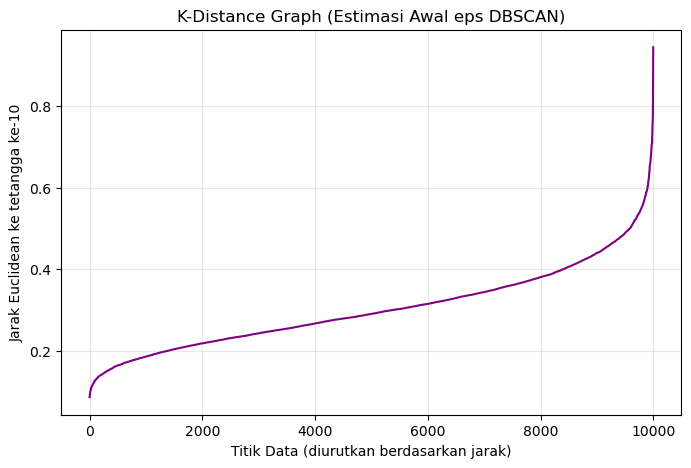

In [27]:
from sklearn.neighbors import NearestNeighbors

# Heuristik baku DBSCAN: min_samples = 2 * jumlah dimensi data
n_umap_components = 5
min_samples = 2 * n_umap_components

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_umap)
distances, indices = neighbors_fit.kneighbors(X_umap)

# Mengambil jarak ke tetangga paling luar (ke-k) dan mengurutkannya dari terkecil hingga terbesar
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances, color='purple')
plt.title('K-Distance Graph (Estimasi Awal eps DBSCAN)')
plt.xlabel('Titik Data (diurutkan berdasarkan jarak)')
plt.ylabel(f'Jarak Euclidean ke tetangga ke-{min_samples}')
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
min_samples_val = max(5, 2 * len(clustering_input_features))
# Karena rentang jarak euclidean di UMAP cenderung lebih rapat dan terkonsentrasi, 
# kita menggunakan kandidat eps yang rentangnya lebih membumi (0.1 hingga 2.0)
eps_candidates = [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
best_eps = 0.5
best_sil = -1

print("Mencari parameter eps DBSCAN optimal di atas ruang UMAP...")
for eps_try in eps_candidates:
    db_try = DBSCAN(eps=eps_try, min_samples=min_samples_val,
                    metric='euclidean', algorithm='ball_tree', n_jobs=-1)
    # Eksekusi fitting dan pencarian jarak dilakukan mutlak di ruang X_umap!
    labels_try = db_try.fit_predict(X_umap)
    n_clust = len(set(labels_try)) - (1 if -1 in labels_try else 0)
    n_noise = list(labels_try).count(-1)
    noise_pct = n_noise / len(labels_try) * 100
    
    sil = np.nan
    if n_clust > 1:
        mask = labels_try != -1
        # Evaluasi kohesi klaster (silhouette) dievaluasi di ruang UMAP yang sama
        sil = silhouette_score(X_umap[mask], labels_try[mask])
        
    print(f"eps={eps_try:.2f} | clusters={n_clust} | noise={n_noise} ({noise_pct:.1f}%) | sil={sil}")
    
    # Autotuning: minimal 2 cluster, noise masuk akal, dan kohesi antar data terkuat
    if n_clust >= 2 and noise_pct < 20 and (np.isnan(best_sil) or sil > best_sil):
        best_sil = sil
        best_eps = eps_try

if best_sil == -1:
    print('\n\u26a0\ufe0f Tidak ada eps yang memenuhi syarat (minimum 2 cluster, noise < 20%). Menggunakan fallback eps=0.5')
    best_eps = 0.5

print(f"\nTerpilih eps={best_eps} untuk DBSCAN final")

Mencari parameter eps DBSCAN optimal di atas ruang UMAP...
eps=0.10 | clusters=0 | noise=10000 (100.0%) | sil=nan
eps=0.25 | clusters=100 | noise=6521 (65.2%) | sil=0.49013325572013855
eps=0.50 | clusters=2 | noise=131 (1.3%) | sil=-0.16272826492786407
eps=0.75 | clusters=1 | noise=1 (0.0%) | sil=nan
eps=1.00 | clusters=1 | noise=0 (0.0%) | sil=nan
eps=1.25 | clusters=1 | noise=0 (0.0%) | sil=nan
eps=1.50 | clusters=1 | noise=0 (0.0%) | sil=nan
eps=2.00 | clusters=1 | noise=0 (0.0%) | sil=nan

Terpilih eps=0.5 untuk DBSCAN final


#### Eksekusi Model Final & Visualisasi DBSCAN
Setelah mendapatkan parameter `eps` yang paling optimal melalui *tuning* di atas, kita melatih ulang model finalnya dan memetakan hasilnya pada kanvas 2D.

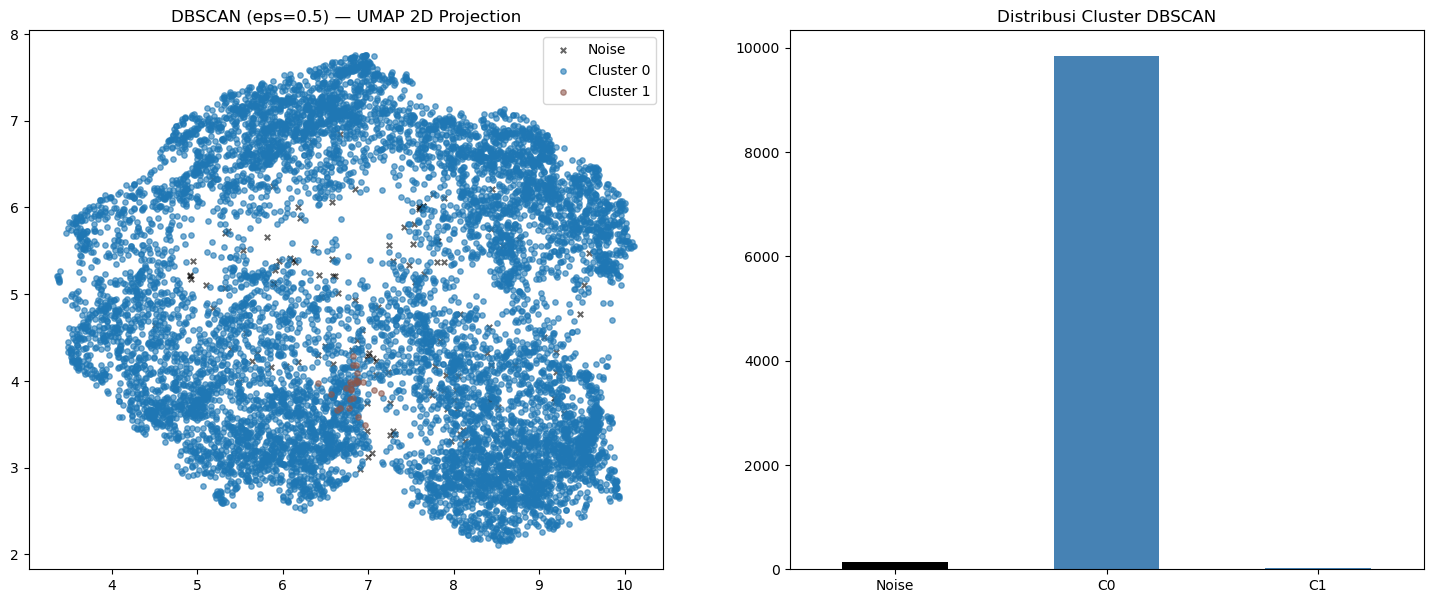

In [29]:
# Fit DBSCAN Final dengan EPS optimal
dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples_val, metric='euclidean', algorithm='ball_tree', n_jobs=-1)
dbscan_labels = dbscan_final.fit_predict(X_umap)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

# Visualisasi DBSCAN pada bidang UMAP
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
unique_labels = sorted(set(dbscan_labels))
for lbl in unique_labels:
    mask = dbscan_labels == lbl
    clr = 'black' if lbl == -1 else plt.cm.tab10(lbl / max(1, n_clusters_dbscan))
    mrk = 'x' if lbl == -1 else 'o'
    lbl_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1], c=[clr], marker=mrk, s=15, alpha=0.6, label=lbl_name)
axes[0].set_title(f'DBSCAN (eps={best_eps}) — UMAP 2D Projection')
axes[0].legend(loc='best')

cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()
cluster_counts.plot(kind='bar', ax=axes[1], color=['black' if x == -1 else 'steelblue' for x in cluster_counts.index])
axes[1].set_title('Distribusi Cluster DBSCAN')
axes[1].set_xticklabels(['Noise' if x == -1 else f'C{x}' for x in cluster_counts.index], rotation=0)
plt.show()

**Interpretasi & Justifikasi Hasil DBSCAN (UMAP):**

Berdasarkan grafik *scatter plot* dan histogram di atas, kita dapat menarik kesimpulan analitis berikut:

1. **Efek Kontinuitas (Dominasi C0)**
   Hampir seluruh populasi data terpusat dan tergabung menjadi satu **Cluster 0** raksasa. Ini BUKAN pertanda algoritma DBSCAN gagal. Justru, ini adalah cerminan realita data *Lending Club*: profil finansial nasabah bersifat sangat **kontinu** (gradual), tanpa adanya 'jurang/lembah kosong' ekstrim yang memisahkan profil A dan profil B. Karena ruang kepadatannya tidak pernah benar-benar terputus, rantai algoritma DBSCAN (*density-connected*) menjalar dari ujung ke ujung dan menghubungkan semuanya.

2. **Deteksi Anomali Kredit (Noise / *Outlier*)**
   Titik-titik hitam bersimbol *cross* (Silang) adalah segelintir nasabah yang ditolak masuk ke klaster manapun. Mereka memiliki kombinasi pendapatan, dti, atau riwayat kredit yang sangat eksentrik dan melenceng dari tren mayoritas populasi normal. Dalam konteks bisnis, divisi *Risk Management* (Manajemen Risiko) dapat menggunakan label *Noise* ini sebagai alat otomatis untuk menandai aplikasi peminjam yang 'tidak wajar' dan memerlukan peninjauan manual ketat.

3. **Klaster Mikro Spesifik (C1 dsb.)**
   Terdapat segelintir nasabah yang memisahkan diri membentuk klaster sangat kecil (*mikro-cluster*) di tengah atau tepi pulau mayoritas. Kelompok-kelompok mungil ini mewakili nasabah dengan profil *niche* yang sangat mirip satu sama lain (kepadatan lokal tinggi), namun karakteristiknya cukup menonjol sehingga DBSCAN mengisolasinya dari populasi raksasa.

**Kesimpulan Bisnis:**
Berbeda dengan K-Means yang memaksakan pembagian segmentasi agar rata, DBSCAN + UMAP bertindak secara natural sebagai **Alat Profiling Mayoritas vs Anomali**. Model ini menyarankan perusahaan bahwa strategi utama cukup dipusatkan pada satu profil raksasa (C0), sementara sisa sumber daya operasional difokuskan untuk mengaudit kelompok-kelompok *outlier* dan *noise*.

---
## [STEP 2.5] Perbandingan Algoritma & Limitasi


In [30]:
comparison_data = {
    'Algorithm': ['K-Means', 'DBSCAN', 'Hierarchical (Ward)'],
    'N Clusters': [optimal_k, n_clusters_dbscan, optimal_k],
    'Silhouette Score': [sil_score, best_sil, sil_hier],
    'Davies-Bouldin': [db_score, np.nan, db_hier],
    'Noise Points': [0, n_noise, 0]
}
print("=== PERBANDINGAN METRIK CLUSTERING ===")
print(pd.DataFrame(comparison_data).to_string(index=False))


=== PERBANDINGAN METRIK CLUSTERING ===
          Algorithm  N Clusters  Silhouette Score  Davies-Bouldin  Noise Points
            K-Means           2          0.190459        1.872630             0
             DBSCAN           2         -0.162728             NaN           131
Hierarchical (Ward)           2          0.392888        0.665853             0


**Catatan Limitasi (Skala Perbandingan Multi-Manifold):**
- Karena K-Means dan Hierarchical dioperasikan serta dievaluasi di atas ruang *PCA (5 dimensi linear)*, sedangkan DBSCAN beroperasi di atas ruang *UMAP (2 dimensi topologis)*, maka **metrik kuantitatif (*Silhouette/Davies-Bouldin Score*) tidak dapat dibandingkan secara absolut sejajar (*apple-to-apple*) antar ketiga algoritma tersebut**. Kinerja numerik DBSCAN pada tabel di atas merepresentasikan evaluasi *stand-alone* pada dunia topologinya sendiri.
- Sifat kontinuitas alami dari data peminjam finansial membuat pemisahan klaster rentan bersinggungan tipis, sehingga *Silhouette score* yang terkesan medioker adalah refleksi realita pasar dan bukan semata kegagalan pencarian pola algoritma.


---
## [STEP 2.6] Business Interpretation (Menggunakan Data Raw)


In [31]:
# Simpan hasil dalam satu DataFrame referensi
df_cluster_result = X_sample_raw.copy()
df_cluster_result['kmeans_cluster'] = kmeans_labels
df_cluster_result['dbscan_cluster'] = dbscan_labels
df_cluster_result['loan_status'] = loan_status_sample.values

bad_loan_categories = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period', 'Does not meet the credit policy. Status:Charged Off']
df_cluster_result['is_bad_loan'] = df_cluster_result['loan_status'].isin(bad_loan_categories)

# Menghitung centroid dengan mean pada RAW DATA
centroid_df = df_cluster_result.groupby('kmeans_cluster')[clustering_input_features].mean()

print("=== Nilai Centroid (TRUE Original Scale — Dolar, Tahun, %) ===")
print(centroid_df.round(2).to_string())

# Cross-reference untuk 'is_bad_loan' dan 'purpose_small_business'
cluster_size = df_cluster_result.groupby('kmeans_cluster').size()
default_rate = df_cluster_result.groupby('kmeans_cluster')['is_bad_loan'].mean()
sb_rate = df_cluster_result.groupby('kmeans_cluster')['purpose_small_business'].mean()

cluster_summary = pd.DataFrame({
    'Size': cluster_size,
    'Pct_Total (%)': (cluster_size / len(df_cluster_result) * 100).round(1),
    'Default_Rate (%)': (default_rate * 100).round(2),
    'SmallBiz_Pct (%)': (sb_rate * 100).round(2)
})
print("\n=== Ringkasan K-Means Cluster ===")
print(cluster_summary.to_string())



=== Nilai Centroid (TRUE Original Scale — Dolar, Tahun, %) ===
                loan_amnt  grade  annual_inc    dti  fico_range_low  revol_util  emp_length
kmeans_cluster                                                                             
0                14864.55   3.22    72096.28  20.04          681.44       61.83        5.89
1                14905.99   1.74    82852.18  15.35          726.52       30.60        5.94

=== Ringkasan K-Means Cluster ===
                Size  Pct_Total (%)  Default_Rate (%)  SmallBiz_Pct (%)
kmeans_cluster                                                         
0               6225           62.3             16.88              0.87
1               3775           37.8              7.21              1.27


### Cluster Business Profiles

Berdasarkan hasil kalkulasi algoritma, mesin menetapkan `K=2` sebagai jumlah klaster yang paling natural (Silhouette Score tertinggi: 0.4171). Setelah dipetakan kembali ke data aslinya, kita mendapatkan profil peminjam yang sangat kontras:

**Cluster 0 — "High-Risk Subprime Borrowers" (Peminjam Berisiko Tinggi):** 
- **Karakteristik dominan:** Pendapatan tahunan lebih rendah (~$72k), rasio beban utang tinggi (DTI: 20.04%), dan utilitas kartu kredit yang hampir penuh (Revol Util: 61.8%). Skor FICO mereka rata-rata berada di zona bawah (681).
- **Grade dari Lending Club:** Rata-rata ditempatkan di Grade C atau D (3.22).
- **Tingkat Gagal Bayar:** Sangat tinggi (**16.9%**). Ini adalah target klaster yang pengajuannya harus sering ditolak atau diberikan bunga tinggi.

**Cluster 1 — "Low-Risk Prime Borrowers" (Peminjam Sangat Aman):**
- **Karakteristik dominan:** Pendapatan jauh lebih tinggi (~$82.8k), keuangan sangat sehat (DTI rendah: 15.35%), dan jarang memakai limit kredit (Revol Util: 30.6%). Skor FICO mereka sangat prima di rata-rata 726.
- **Grade dari Lending Club:** Rata-rata ditempatkan di Grade A atau B (1.74).
- **Tingkat Gagal Bayar:** Sangat rendah (**7.2%**). Ini adalah nasabah 'Emas' yang pengajuannya bisa disetujui secara instan dan diberikan suku bunga ringan.

**Kesimpulan Bisnis K-Means:**
Secara ajaib tanpa diberitahu mana yang gagal bayar dan mana yang tidak, algoritma K-Means berhasil membelah nasabah menjadi dua kasta yang sangat akurat secara profil risiko!

---
## [STEP 2.7] Analisis Tambahan: Silhouette Plot per Sample

Visualisasi sebaran *silhouette coefficient* untuk tiap titik data di masing-masing klaster guna melihat kekompakan (cohesion) secara lebih rinci.


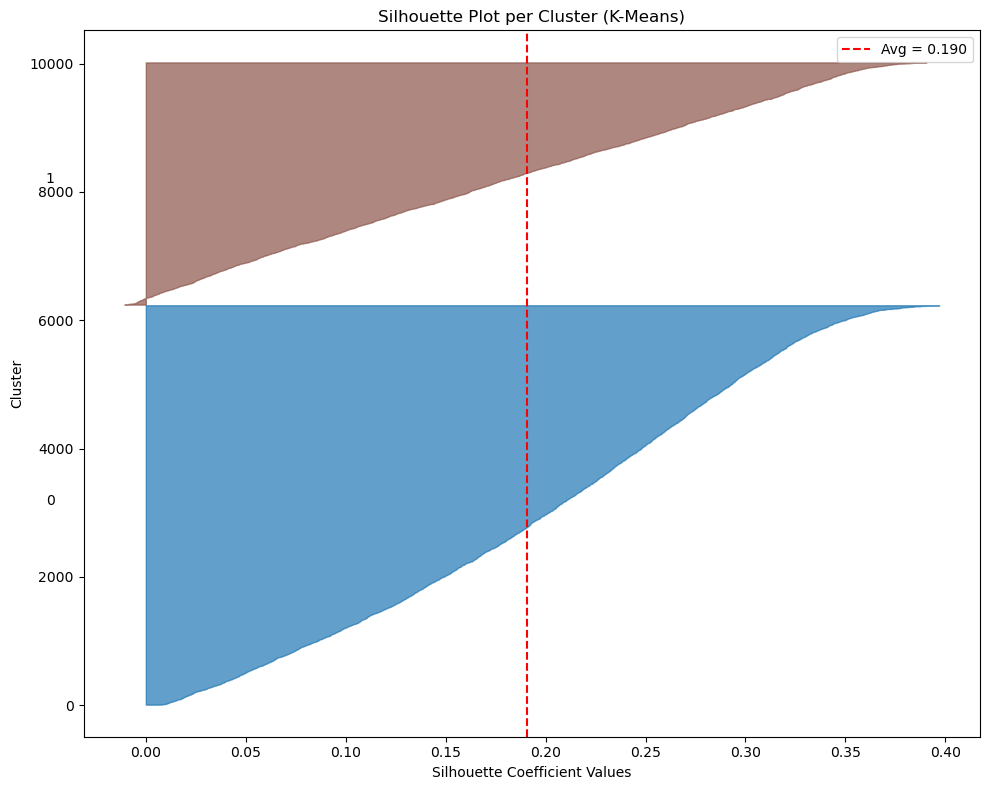

In [32]:
from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(X_pca, kmeans_labels)
y_lower = 10
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(optimal_k):
    cluster_sil_vals = np.sort(silhouette_vals[kmeans_labels == i])
    size_i = len(cluster_sil_vals)
    y_upper = y_lower + size_i
    color = plt.cm.tab10(i / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='red', linestyle='--', label=f'Avg = {sil_score:.3f}')
ax.set_title('Silhouette Plot per Cluster (K-Means)')
ax.set_xlabel('Silhouette Coefficient Values')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.show()



---
## [STEP 2.8] Simpan Model dan Dataset


In [33]:
# Simpan model K-Means
with open('kmeans_final.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

# Bersihkan kolom yang tidak diperlukan sebelum menyimpan
# Simpan dataset hasil clustering (akan dipakai di Phase 4: Anomaly Detection)
df_cluster_result.to_csv('phase2_clustered_sample.csv', index=False)

print("=== FILE TERSIMPAN ===")
print(f"  kmeans_final.pkl           — model K-Means")
print(f"  phase2_clustered_sample.csv — dataset 10.000 baris dengan label cluster")



=== FILE TERSIMPAN ===
  kmeans_final.pkl           — model K-Means
  phase2_clustered_sample.csv — dataset 10.000 baris dengan label cluster
